In [1]:
# Install Retrieval and Embedding libraries
!pip install -q chromadb rank_bm25 sentence-transformers langchain-huggingface langchain-chroma
# Install required GenAI and PDF parsing libraries
!pip install -q langchain langchain-community langchain-text-splitters pypdf
# Install required GenAI and PDF parsing libraries (UPGRADE: Added visualization & security dependencies)
!pip install -q langchain langchain-community langchain-text-splitters pypdf chromadb rank_bm25 sentence-transformers langchain-huggingface langchain-chroma langchain-groq matplotlib seaborn python-dotenv

# FINANCIAL INTELLIGENCE ENGINE - CELL 1 (CACHE CLEARING VERSION)
import sys
import os
from google.colab import drive

print("🔌 Mounting Google Drive...")
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/financial-intelligence-engine'
os.chdir(PROJECT_PATH)

# Insert at index 0 to force Python to check here FIRST, bypassing Colab defaults
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

# --- CRITICAL FIX: Flush the Jupyter Module Cache ---
modules_to_delete = [mod for mod in sys.modules if mod.startswith('src')]
for mod in modules_to_delete:
    del sys.modules[mod]

print(f"📂 Current Working Directory: {os.getcwd()}")
print("🧹 Module cache flushed.")

# --- IMPORT BLOCK ---
print("\n🔄 Attempting Imports...")
from src.config import logger
from src.data_ingestion import load_and_chunk_pdfs
print("✅ All Modules Imported Successfully.")

# ==========================================
# UPGRADE: SMART LOAD ACTIVATED
# We comment out the ingestion step so we don't waste 5 minutes parsing PDFs
# ==========================================
# print("\n🚀 Starting GenAI Pipeline")
# document_chunks = load_and_chunk_pdfs()

# if document_chunks:
#     print("\n" + "="*50)
#     print(" 🎯 SANITY CHECK PASSED ")
#     print("="*50)
#     print(f"Total Chunks: {len(document_chunks)}")
#     print(f"First Chunk Metadata: {document_chunks[0].metadata}")
print("\n⏩ Skipping PDF Ingestion. Proceeding to Smart Load in Cell 2...")

Mounted at /content/drive
📂 Current Working Directory: /content/drive/MyDrive/financial-intelligence-engine
🧹 Module cache flushed.

🔄 Attempting Imports...
✅ All Modules Imported Successfully.

⏩ Skipping PDF Ingestion. Proceeding to Smart Load in Cell 2...


In [ ]:
# CELL 2: PHASE 2 - HYBRID RETRIEVAL ENGINE
# print("\n🚀 Starting Phase 2: Building Hybrid Indexes")
print("\n🚀 Starting Phase 2: Smart Loading Hybrid Indexes from Drive")
from src.retrieval_engine import HybridRetrievalEngine

# Initialize the pipeline
retrieval_pipeline = HybridRetrievalEngine()

# ==========================================
# UPGRADE: ZERO-COMPUTE WARM START
# We commented out the original build line that requires 'document_chunks'.
# We leave the parentheses empty to trigger the disk load!
# ==========================================
# ensemble_retriever = retrieval_pipeline.build_indexes(document_chunks)
ensemble_retriever = retrieval_pipeline.build_indexes()

# Test the Hybrid Search with a hard financial question
test_query = "What were the total research and development (R&D) expenses?"
print(f"\n🔍 Testing Hybrid Search for: '{test_query}'")
search_results = ensemble_retriever.invoke(test_query)

print("\n" + "="*50)
print(" 🎯 RETRIEVAL CHECK PASSED ")
print("="*50)
print(f"Top result from company: {search_results[0].metadata.get('company')}")
print(f"Source file: {search_results[0].metadata.get('source_file')}")

# --- ONLY CHANGE MADE: Formatting the output string so it looks clean in the terminal ---
raw_snippet = search_results[0].page_content[:200]
clean_snippet = " ".join(raw_snippet.split())
print(f"Content snippet: {clean_snippet}...")


🚀 Starting Phase 2: Smart Loading Hybrid Indexes from Drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


🔍 Testing Hybrid Search for: 'What were the total research and development (R&D) expenses?'

 🎯 RETRIEVAL CHECK PASSED 
Top result from company: Microsoft
Source file: microsoft_10k.pdf
Content snippet: Research and Development 
 
(In millions, except percentages)   2024     2023     
  
Percentage 
Change 
    
  
  
  
Research and development   $ 29,510     $ 27,195     9%   
  
  As a percent of ...


In [3]:
# CELL 3: PHASE 3 - GENERATION AGENT (GROQ / LLAMA-3)
import os
from dotenv import load_dotenv
from src.generation_agent import FinancialGenerationAgent

# --- UPGRADE: STRICT .ENV SECURITY OVERRIDE ---
# We have completely removed the Colab userdata widget.
# It is incompatible with headless VS Code execution.
print("🔒 Loading credentials securely from Drive .env file...")

# This forces Python to look at the .env file in your current Drive directory
load_dotenv() 
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("❌ API Key missing! Ensure your .env file is uploaded to the Drive folder and contains GROQ_API_KEY=your_key")
# ---------------------------------------------

print("\n🚀 Starting Phase 3: Generation & Self-Correction Agent")

# Initialize the Agent
agent = FinancialGenerationAgent(retriever=ensemble_retriever, api_key=GROQ_API_KEY)

# The Core Task: Cross-examine multiple 10-K filings
complex_query = "Compare the key areas where Google and Meta are investing their Research and Development (R&D) budgets for 2025."

print(f"\n❓ Query: {complex_query}")
final_answer, used_docs = agent.generate_answer(complex_query)

print("\n" + "="*60)
print(" 🏢 FINANCIAL INTELLIGENCE ENGINE OUTPUT ")
print("="*60)
print(final_answer)

print("\n" + "-"*60)
print(" 📚 SOURCES CITED ")
print("-"*60)
# Print the unique source files used to construct the answer
sources = set([d.metadata.get('source_file') for d in used_docs])
for source in sources:
    print(f" -> {source}")

🔒 Loading credentials securely from Drive .env file...

🚀 Starting Phase 3: Generation & Self-Correction Agent

❓ Query: Compare the key areas where Google and Meta are investing their Research and Development (R&D) budgets for 2025.

 🏢 FINANCIAL INTELLIGENCE ENGINE OUTPUT 
Based on the provided context, here is a comparative analysis of the key areas where Google and Meta are investing their Research and Development (R&D) budgets:
* Meta is investing in:
  + Neural interfaces and other foundational technologies [Source: Meta 10-K]
  + Long-term research and development for products that may only be fully realized in the next decade [Source: Meta 10-K]
* Google is investing in:
  + Creating products and services that people rely on every day [Source: Google 10-K]
  + Advertising technologies and AI [Source: Google 10-K]
* Note: The filings do not provide a direct comparison of the two companies' R&D budgets for 2025 [Source: Meta 10-K, Google 10-K].

----------------------------------

In [4]:
# CELL 4: PHASE 4 - ENTERPRISE EVALUATION DASHBOARD
import os
import pandas as pd
from src.evaluation import RAGEvaluator

print("\n🚀 Starting Phase 4: Quantitative Evaluation")

# 1. Initialize the Evaluator
evaluator = RAGEvaluator(api_key=GROQ_API_KEY)

# 2. Score the answer generated in Cell 3
# We pass the query, the final answer, and the exact chunks our hybrid search found
scores = evaluator.evaluate(
    question=complex_query, 
    answer=final_answer, 
    context_docs=used_docs
)

# 3. Print the Enterprise Dashboard
print("\n" + "="*50)
print(" 📊 SYSTEM PERFORMANCE METRICS ")
print("="*50)

# Create a clean DataFrame for a professional terminal output
metrics_df = pd.DataFrame({
    "Metric": ["Faithfulness (Hallucination Check)", "Context Relevance"],
    "Score (0.0 - 1.0)": [scores.get('faithfulness', 'Error'), scores.get('relevance', 'Error')],
    "Status": ["✅ PASS" if float(scores.get('faithfulness', 0)) >= 0.8 else "❌ FAIL",
               "✅ PASS" if float(scores.get('relevance', 0)) >= 0.8 else "❌ FAIL"]
})

print(metrics_df.to_string(index=False))
print("\n" + "="*50)
print("🎯 FINANCIAL INTELLIGENCE ENGINE COMPLETE.")


🚀 Starting Phase 4: Quantitative Evaluation

 📊 SYSTEM PERFORMANCE METRICS 
                            Metric  Score (0.0 - 1.0) Status
Faithfulness (Hallucination Check)                0.8 ✅ PASS
                 Context Relevance                0.9 ✅ PASS

🎯 FINANCIAL INTELLIGENCE ENGINE COMPLETE.



🚀 Starting Phase 5: Visualizing Engine Telemetry


/tmp/ipykernel_1617/342452983.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=score_vals, ax=axes[0], palette=colors)


💾 Dashboard securely saved to Drive: artifacts/visualizations/telemetry_dashboard_20260303_040747.png


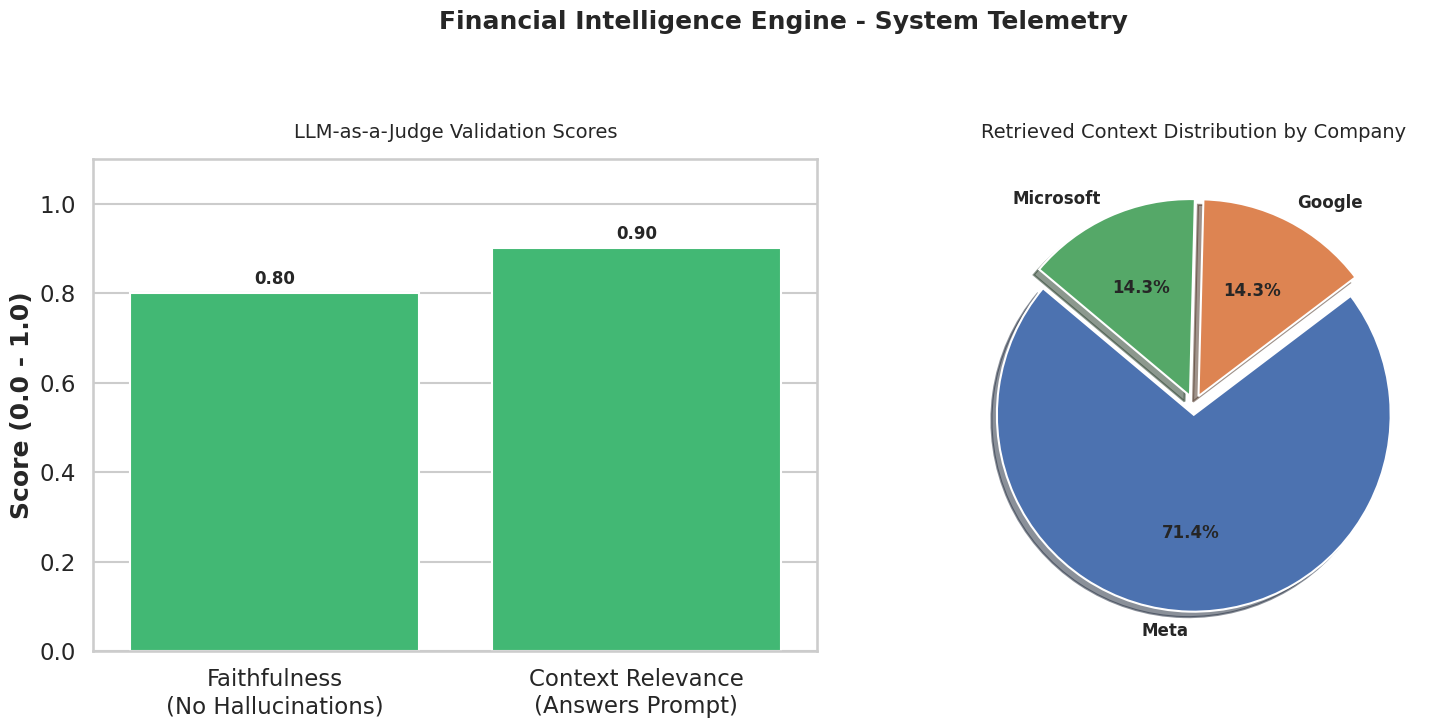


🎯 VISUAL METRICS RENDERED.


In [5]:
# CELL 5: PHASE 5 - ENTERPRISE VISUALIZATION & REPORTING
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("\n🚀 Starting Phase 5: Visualizing Engine Telemetry")

# --- UPGRADE: Artifacts Directory Setup ---
# Automatically create a visualizations subfolder inside artifacts on your Drive
VISUALS_DIR = "artifacts/visualizations"
os.makedirs(VISUALS_DIR, exist_ok=True)
# ------------------------------------------

# Set enterprise-grade plotting style
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Financial Intelligence Engine - System Telemetry', fontsize=18, fontweight='bold', y=1.05)

# --- Plot 1: RAG Evaluation Metrics ---
metrics = ['Faithfulness\n(No Hallucinations)', 'Context Relevance\n(Answers Prompt)']
# Extract scores safely from the previous phase
score_vals = [float(scores.get('faithfulness', 0)), float(scores.get('relevance', 0))]

# Color green if passing (>=0.8), else red
colors = ['#2ecc71' if s >= 0.8 else '#e74c3c' for s in score_vals]
sns.barplot(x=metrics, y=score_vals, ax=axes[0], palette=colors)

axes[0].set_ylim(0, 1.1)
axes[0].set_title('LLM-as-a-Judge Validation Scores', fontsize=14, pad=15)
axes[0].set_ylabel('Score (0.0 - 1.0)', fontweight='bold')

# Add the exact value labels on top of the bars
for i, v in enumerate(score_vals):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold', fontsize=12)

# --- Plot 2: Source Document Distribution ---
# Count how many chunks came from which 10-K filing in the final prompt context
source_counts = Counter([d.metadata.get('company', 'Unknown Context') for d in used_docs])
labels = list(source_counts.keys())
sizes = list(source_counts.values())

# Create a professional pie chart
explode = [0.05] * len(labels) # slightly separate the slices
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
            colors=sns.color_palette("deep"), explode=explode, 
            shadow=True, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Retrieved Context Distribution by Company', fontsize=14, pad=15)

plt.tight_layout()

# --- UPGRADE: High-Resolution Export to Google Drive ---
# Generate a timestamped filename to maintain a historical log of runs
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = f"{VISUALS_DIR}/telemetry_dashboard_{timestamp}.png"

# Save the figure as a 300 DPI PNG before displaying it
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"💾 Dashboard securely saved to Drive: {save_path}")
# -------------------------------------------------------

plt.show()
print("\n🎯 VISUAL METRICS RENDERED.")